In [20]:
# Importar librerías necesarias

# Librerías estándar de Python
import json

# Librerías de terceros
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression

# ==============================
# CONFIGURACIÓN DE DISPOSITIVO
# ==============================

# Selecciona GPU si está disponible, de lo contrario usa CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Muestra el dispositivo que se está utilizando
print(f"Usando: {device}")

Usando: cpu


In [21]:
#Cargar datos y definir target

df = pd.read_csv("data_loan_clean.csv", low_memory=False)
cols = json.load(open("esquema_modelo.json"))["columnas_modelo"]
cols = [c for c in cols if c not in ["loan_status", "default", "verification_status_joint"]]

status_map = {
    "Fully Paid":                                          0,
    "Does not meet the credit policy. Status:Fully Paid":  0,
    "Charged Off":                                         1,
    "Default":                                             1,
    "Late (31-120 days)":                                  1,
    "Does not meet the credit policy. Status:Charged Off": 1,
}

df = df[df["loan_status"].isin(status_map)].copy()
df["default"] = df["loan_status"].map(status_map)

print(f"Filas para modelo: {len(df):,}")
print(df["default"].value_counts(normalize=True).mul(100).round(2))

Filas para modelo: 268,530
default
0    78.1
1    21.9
Name: proportion, dtype: float64


In [22]:
# ── 2. Separar X e y ───────────────────────────────────────────────
X = df[cols]
y = df["default"].values

print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")


Shape X: (268530, 66)
Shape y: (268530,)


In [23]:
# ── 3. Train / Test split ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"Default en train: {y_train.mean()*100:.2f}%")
print(f"Default en test:  {y_test.mean()*100:.2f}%")



Train: (214824, 66) | Test: (53706, 66)
Default en train: 21.90%
Default en test:  21.90%


In [24]:
# ── 4. Imputar NaN con mediana ─────────────────────────────────────
imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=cols
)
X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=cols
)

print(f"\nNaN restantes en X_train: {X_train.isnull().sum().sum()}")



NaN restantes en X_train: 0


In [25]:
# ── 5. Escalar variables ───────────────────────────────────────────
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [26]:
# ── 6. Entrenar modelo ─────────────────────────────────────────────
modelo = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train_scaled, y_train)
print("\nModelo entrenado ✓")

d:\RNA-Trabajo-2-main\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Modelo entrenado ✓


In [27]:
# ── 7. Predicciones ────────────────────────────────────────────────
y_pred = modelo.predict(X_test_scaled)
y_prob = modelo.predict_proba(X_test_scaled)[:, 1]

In [28]:
# ── 8. Métricas ────────────────────────────────────────────────────
print("\n── Classification Report ──────────────────────────────────")
print(classification_report(y_test, y_pred,
                             target_names=["No Default (0)", "Default (1)"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


── Classification Report ──────────────────────────────────
                precision    recall  f1-score   support

No Default (0)       0.86      0.65      0.74     41942
   Default (1)       0.34      0.63      0.44     11764

      accuracy                           0.65     53706
     macro avg       0.60      0.64      0.59     53706
  weighted avg       0.75      0.65      0.67     53706

ROC-AUC: 0.6896


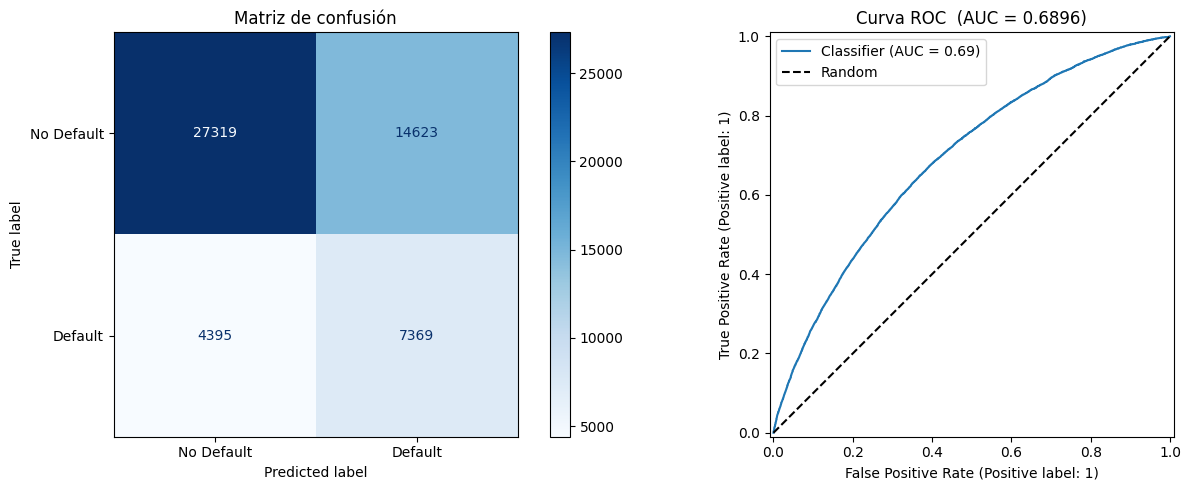

In [29]:
# ── 9. Visualizaciones ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No Default", "Default"],
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Matriz de confusión")

# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title(f"Curva ROC  (AUC = {roc_auc_score(y_test, y_prob):.4f})")
axes[1].plot([0, 1], [0, 1], "k--", label="Random")
axes[1].legend()

plt.tight_layout()
plt.show()


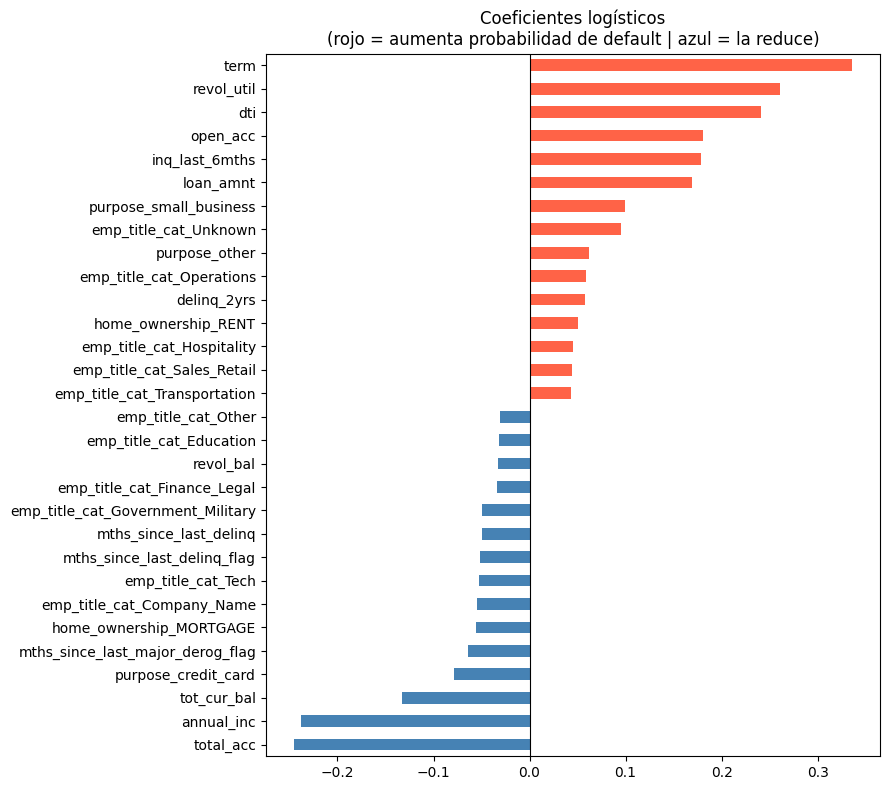


Top 10 variables que MÁS aumentan default:
term                        0.335880
revol_util                  0.260561
dti                         0.240643
open_acc                    0.180954
inq_last_6mths              0.178504
loan_amnt                   0.169683
purpose_small_business      0.099563
emp_title_cat_Unknown       0.095239
purpose_other               0.062320
emp_title_cat_Operations    0.058947

Top 10 variables que MÁS reducen default:
mths_since_last_delinq             -0.049316
mths_since_last_delinq_flag        -0.051401
emp_title_cat_Tech                 -0.053126
emp_title_cat_Company_Name         -0.054253
home_ownership_MORTGAGE            -0.055298
mths_since_last_major_derog_flag   -0.064330
purpose_credit_card                -0.078286
tot_cur_bal                        -0.132880
annual_inc                         -0.238029
total_acc                          -0.245531


In [30]:
# ── 10. Coeficientes ───────────────────────────────────────────────
coeficientes = pd.Series(
    modelo.coef_[0],
    index=cols
).sort_values(ascending=False)

# Top 15 positivos y negativos
top_n = 15
top_coefs = pd.concat([
    coeficientes.head(top_n),
    coeficientes.tail(top_n)
]).sort_values()

colores = ["steelblue" if v < 0 else "tomato" for v in top_coefs]

top_coefs.plot(kind="barh", figsize=(9, 8), color=colores)
plt.title("Coeficientes logísticos\n"
          "(rojo = aumenta probabilidad de default | "
          "azul = la reduce)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nTop 10 variables que MÁS aumentan default:")
print(coeficientes.head(10).to_string())

print("\nTop 10 variables que MÁS reducen default:")
print(coeficientes.tail(10).to_string())
